In [1]:
#!pip install chess asyncio

In [2]:
from stockfish import Stockfish
import chess.pgn
import chess.engine
import io
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import asyncio
import chess.svg
from IPython.display import SVG, display, clear_output


#solves chess.engine dependency
asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())


## Variables for user to change


In [3]:
STOCKFISH_PATH  = "C:\\Users\\user\\PycharmProjects\\Databases\\stockfish-windows-x86-64-avx2\\stockfish\\stockfish-windows-x86-64-avx2.exe"
DEPTH = 20

In [4]:
game_pgn = """
[Event "Live Chess"]
[Site "Chess.com"]
[Date "2026.09.11"]
[Round "?"]
[White "AlphaQQT"]
[Black "rajakel"]
[Result "0-1"]
[TimeControl "180"]
[WhiteElo "641"]
[BlackElo "645"]
[Termination "rajakel won by checkmate"]
[Link "https://www.chess.com/game/174312795136"]

1. d4 Nf6 2. Bf4 d6 3. e3 g6 4. Nf3 Bg7 5. Bd3 Nc6 6. c3 O-O 7. Nbd2 Re8 8. Ne4
Nxe4 9. Bxe4 d5 10. Bd3 e5 11. dxe5 Nxe5 12. h4 Nxf3+ 13. Qxf3 c5 14. h5 d4 15.
cxd4 cxd4 16. h6 Qa5+ 17. Ke2 dxe3 18. Bxe3 Bxb2 19. Rab1 Qxa2 20. Be4 Bd4+ 21.
Kd3 Rd8 22. Bxd4 Qa3+ 23. Kc4 Be6+ 24. Kb5 Qa6+ 25. Kb4 Rxd4+ 26. Kc3 Qc4+ 27.
Kb2 Rd2+ 28. Ka1 Qa2# 0-1
"""

In [5]:
#optional, in case pasted directly from chess.com, to extract only the pgn
game_pgn = "1." + game_pgn.split("\n1.")[1]
game_pgn

'1. d4 Nf6 2. Bf4 d6 3. e3 g6 4. Nf3 Bg7 5. Bd3 Nc6 6. c3 O-O 7. Nbd2 Re8 8. Ne4\nNxe4 9. Bxe4 d5 10. Bd3 e5 11. dxe5 Nxe5 12. h4 Nxf3+ 13. Qxf3 c5 14. h5 d4 15.\ncxd4 cxd4 16. h6 Qa5+ 17. Ke2 dxe3 18. Bxe3 Bxb2 19. Rab1 Qxa2 20. Be4 Bd4+ 21.\nKd3 Rd8 22. Bxd4 Qa3+ 23. Kc4 Be6+ 24. Kb5 Qa6+ 25. Kb4 Rxd4+ 26. Kc3 Qc4+ 27.\nKb2 Rd2+ 28. Ka1 Qa2# 0-1\n'

In [6]:
def plot_eval_graph(scores, clip=800, markers=None):
    """
    Chess.com-style evaluation graph.

    Evaluations are shifted upward by `clip`, so:
        - -clip  -> 0
        -    0   -> clip
        - +clip  -> 2*clip

    This keeps the equality line permanently centered while allowing
    the entire evaluation area to be filled down to zero.

    Parameters
    ----------
    scores : list
        List of chess.engine.Cp or Mate scores.

    clip : int, default=800
        Maximum absolute centipawn evaluation displayed.

    markers : list of tuples, optional
        Example:
            [(12, "#f04f3e"), (13, "#5b9bd5")]
    """

    # ---------------------------------------------------------
    # Convert Stockfish evaluations to centipawns
    # ---------------------------------------------------------

    y = []
    mates = []

    for i, s in enumerate(scores):

        if s.is_mate():
            mate = s.mate()
            if s == chess.engine.MateGiven:
                value = y[-1]
            else:
                # Represent mate at the appropriate extreme
                value = clip if mate > 0 else -clip

            y.append(value)
            mates.append((i, mate))

        else:
            cp = s.score()

            # Clip evaluation to [-clip, +clip]
            value = max(-clip, min(clip, cp))

            y.append(value)

    x = list(range(len(y)))

    # ---------------------------------------------------------
    # Shift entire graph upward by `clip`
    # ---------------------------------------------------------
    #
    # Original:
    #
    #       +clip
    #          |
    #        0 |  <- equality
    #          |
    #       -clip
    #
    # Shifted:
    #
    #       2*clip
    #          |
    #       clip |  <- equality
    #          |
    #         0 |
    #
    # This allows fill="tozeroy" to always fill downward.

    offset = clip

    shifted_y = [
        value + offset
        for value in y
    ]

    # Equality line (original y=0)
    equality_y = offset

    # ---------------------------------------------------------
    # Create figure
    # ---------------------------------------------------------

    fig = go.Figure()

    # ---------------------------------------------------------
    # Filled evaluation area
    # ---------------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=x,
            y=shifted_y,

            mode="lines",

            line=dict(
                color="#333333",
                width=1.3
            ),

            # Fill all the way down to y=0
            fill="tozeroy",
            fillcolor="#000000",

            # Keep original evaluation available for hover
            customdata=y,

            hovertemplate=(
                "Move: %{x}<br>"
                "Eval: %{customdata} cp"
                "<extra></extra>"
            ),

            showlegend=False
        )
    )

    # ---------------------------------------------------------
    # Equality / 0 evaluation line
    # ---------------------------------------------------------

    fig.add_hline(
        y=equality_y,

        line=dict(
            color="#888888",
            width=2
        )
    )

    # ---------------------------------------------------------
    # Optional colored move markers
    # ---------------------------------------------------------

    if markers:

        for idx, color in markers:

            if 0 <= idx < len(shifted_y):

                fig.add_trace(
                    go.Scatter(
                        x=[idx],
                        y=[shifted_y[idx]],

                        mode="markers",

                        marker=dict(
                            size=10,
                            color=color,
                            line=dict(
                                color="white",
                                width=1.5
                            )
                        ),

                        customdata=[y[idx]],

                        hovertemplate=(
                            "Move: %{x}<br>"
                            "Eval: %{customdata} cp"
                            "<extra></extra>"
                        ),

                        showlegend=False
                    )
                )

    # ---------------------------------------------------------
    # Mate labels
    # ---------------------------------------------------------

    for idx, mate in mates:

        fig.add_annotation(
            x=idx,
            y=shifted_y[idx],

            text=f"M{abs(mate)}",

            showarrow=False,

            font=dict(
                size=11,
                color="white"
            ),

            yshift=10 if mate > 0 else -10
        )

    # ---------------------------------------------------------
    # Layout
    # ---------------------------------------------------------

    fig.update_layout(

        paper_bgcolor="white",
        plot_bgcolor="white",

        showlegend=False,

        # X axis
        xaxis=dict(
            range=[
                0,
                max(len(x) - 1, 1)
            ],
            showgrid=False,
            showticklabels=False,
            zeroline=False,
            title=None
        ),

        # Y axis
        #
        # Fixed range is important here:
        # 0       = -clip
        # clip    = equality
        # 2*clip  = +clip
        #
        yaxis=dict(
            range=[
                0,
                2 * clip
            ],
            showgrid=False,
            showticklabels=False,
            zeroline=False,
            title=None
        ),

        # Remove all surrounding whitespace
        margin=dict(
            l=0,
            r=0,
            t=0,
            b=0
        ),

        height=250,

        hovermode="x"
    )

    fig.show()

In [7]:
engine = chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH)
engine.configure({
    "Threads": 16,          # set to your CPU cores
    "Hash": 8192,          # MB RAM for Stockfish
})

In [8]:
#wrap string using io library so the chess library can read it as a "file" (thanks chatGPT)
game = chess.pgn.read_game(io.StringIO(game_pgn))

In [9]:
board = game.board()
animation_frames = [chess.svg.board(board=board, size=500)]
rows = []
eval_bar = []

In [10]:
for ply, move in enumerate(game.mainline_moves(), start=1):
    board.push(move)
    animation_frames.append(chess.svg.board(board=board, size=500))
    info = engine.analyse(
        board,
        chess.engine.Limit(depth=DEPTH),
    )

    print(
        ply,
        move.uci(),
        info["score"].white(),
    )
    eval_bar.append(info["score"].black())
engine.quit()

1 d2d4 +35
2 g8f6 +34
3 c1f4 +15
4 d7d6 +34
5 e2e3 +15
6 g7g6 +16
7 g1f3 +14
8 f8g7 +13
9 f1d3 -5
10 b8c6 +13
11 c2c3 -18
12 e8g8 -14
13 b1d2 -30
14 f8e8 -15
15 d2e4 -29
16 f6e4 -25
17 d3e4 -20
18 d6d5 -20
19 e4d3 -24
20 e7e5 -18
21 d4e5 -13
22 c6e5 -8
23 h2h4 -80
24 e5f3 -64
25 d1f3 -103
26 c7c5 +33
27 h4h5 +33
28 d5d4 +59
29 c3d4 -83
30 c5d4 +8
31 h5h6 -76
32 d8a5 +30
33 e1e2 -142
34 d4e3 -158
35 f4e3 -205
36 g7b2 -226
37 a1b1 -239
38 a5a2 -249
39 d3e4 -617
40 b2d4 -513
41 e2d3 -905
42 e8d8 -53
43 e3d4 -40
44 a2a3 -34
45 d3c4 #-7
46 c8e6 #-6
47 c4b5 #-5
48 a3a6 #-4
49 b5b4 #-4
50 d8d4 #-3
51 b4c3 #-3
52 a6c4 #-2
53 c3b2 #-2
54 d4d2 #-2
55 b2a1 #-1
56 c4a2 #-0


In [11]:
plot_eval_graph(eval_bar)

In [12]:
#create_animation(animation_frames)

44


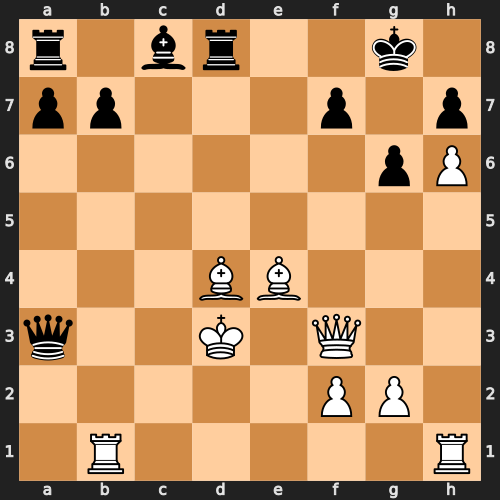

In [18]:
move_number = input("Provide move numer to see board at given move")
print(move_number)
display(SVG(animation_frames[int(move_number)]))